# Simulating a morphological Golgi cell with ``braincell``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/braincell_morphological_golgi_cell.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/braincell_morphological_golgi_cell.ipynb)

This tutorial builds a morphology-aware model of a reconstructed cerebellar Golgi cell with ``braincell``. We load an ASC morphology, discretize it into control volumes, assign membrane properties and ion-channel mechanisms, inject a soma current, and record the resulting membrane voltage.

You will learn how to:

- load and inspect a reconstructed Golgi-cell morphology with ``braincell.Morphology``;
- build a CV-discretized ``braincell.Cell`` from that morphology;
- assign cable properties and Golgi-cell ion-channel mechanisms with ``paint(...)``;
- place a current clamp and voltage probe with ``place(...)``;
- run the simulation with ``Cell.run(...)`` and plot the recorded voltage trace.

For more details on morphology objects, control-volume discretization, region selection, membrane mechanisms, and point stimuli, see the full [braincell documentation](https://brainx.chaobrain.com/braincell/).


In [48]:
import os
import tempfile

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))
os.environ.setdefault("BRAINEVENT_CACHE_DIR", os.path.join(tempfile.gettempdir(), "brainevent-cache"))

import kagglehub
import matplotlib.pyplot as plt
import numpy as np

import brainstate
import brainunit as u
from braincell import Cell, CVPerBranch, Morphology
from braincell.filter import AllRegion, BranchSlice, RootLocation, at
from braincell.mech import CableProperty, Channel, CurrentClamp, Ion, StateProbe


In [49]:
brainstate.environ.set(dt=0.05 * u.ms, precision=64)


## Model helpers

The helper functions below group morphology branches into soma, axon, and dendrite regions. These regions are then used to paint cable properties, ion species, and channel mechanisms onto the reconstructed cell.


In [50]:
def branch_indices_by_type(morphology):
    """Collect branch indices from the reconstructed morphology by broad branch type."""
    groups = {"soma": [], "axon": [], "dendrite": []}

    for fallback_index, branch in enumerate(morphology.branches):
        branch_index = int(getattr(branch, "index", fallback_index))
        branch_type = str(getattr(branch, "type", "")).lower()
        branch_name = str(getattr(branch, "name", "")).lower()

        if "soma" in branch_type or branch_name.startswith("soma"):
            groups["soma"].append(branch_index)
        elif "axon" in branch_type or branch_name.startswith("axon"):
            groups["axon"].append(branch_index)
        elif "dendrite" in branch_type or branch_name.startswith(("dend", "apic", "basal")):
            groups["dendrite"].append(branch_index)

    if not groups["soma"]:
        groups["soma"].append(0)
    return groups


def branch_region(indices):
    indices = list(indices)
    if not indices:
        return None
    return BranchSlice(branch_index=indices, prox=0.0, dist=1.0)


def paint_if_present(cell, region, *mechanisms):
    if region is not None:
        cell.paint(region, *mechanisms)


def build_golgi_cell(morphology, cv_per_branch=1):
    """Build a morphology-aware Golgi-cell model."""
    g_density = u.mS / u.cm**2
    cell = Cell(
        morphology,
        cv_policy=CVPerBranch(cv_per_branch=cv_per_branch),
        solver="staggered",
    )

    branch_groups = branch_indices_by_type(morphology)
    regions = {name: branch_region(indices) for name, indices in branch_groups.items()}

    cell.paint(
        AllRegion(),
        CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
            temperature=u.celsius2kelvin(37.0),
        ),
        Ion("SodiumFixed", name="na", E=60.0 * u.mV),
        Ion("PotassiumFixed", name="k", E=-80.0 * u.mV),
        Channel("IL", g_max=0.03 * g_density, E=-55.0 * u.mV),
    )

    paint_if_present(
        cell,
        regions["soma"],
        Channel("Nav1p6_MA2020_GoC", g_max=150.0 * g_density),
        Channel("Kv1p1_MA2020_GoC", g_max=5.0 * g_density),
        Channel("Kv3p4_MA2020_GoC", g_max=150.0 * g_density),
        Channel("Kv4p3_MA2020_GoC", g_max=4.0 * g_density),
    )
    paint_if_present(
        cell,
        regions["axon"],
        Channel("Nav1p6_MA2020_GoC", g_max=200.0 * g_density),
        Channel("Kv3p4_MA2020_GoC", g_max=12.0 * g_density),
        Channel("HCN1_MA2020_GoC", g_max=0.34 * g_density, E=-20.0 * u.mV),
        Channel("HCN2_MA2020_GoC", g_max=0.31 * g_density, E=-20.0 * u.mV),
    )
    paint_if_present(
        cell,
        regions["dendrite"],
        Channel("Nav1p6_MA2020_GoC", g_max=8.0 * g_density),
        Channel("HCN1_MA2020_GoC", g_max=0.05 * g_density, E=-20.0 * u.mV),
        Channel("HCN2_MA2020_GoC", g_max=0.05 * g_density, E=-20.0 * u.mV),
    )

    return cell, regions, branch_groups


## Morphology

The morphology is downloaded from Kaggle and loaded from the ``golgi.asc`` reconstruction file. After loading, we inspect the morphology metrics and the first few branches to confirm that the soma, axon, and dendrite labels are available for region assignment.


In [51]:
dataset_path = kagglehub.dataset_download("oujago/golgi-cell-morphology-example1")
morphology_path = os.path.join(dataset_path, "golgi.asc")
morphology_path


'C:\\Users\\Administrator\\.cache\\kagglehub\\datasets\\oujago\\golgi-cell-morphology-example1\\versions\\1\\golgi.asc'

In [52]:
golgi_morphology = Morphology.from_asc(morphology_path)

print(golgi_morphology.metric)
print("n branches:", len(golgi_morphology.branches))
print("first branches:")
for branch in golgi_morphology.branches[:8]:
    print(f"  {branch.index}: {branch.name} ({branch.type})")


-----------------------------------
n_branches       | 227
n_stems          | 12
n_bifurcations   | 108
max_branch_order | 13
total_length     | 4985.44 um
mean_radius      | 0.31 um
total_area       | 9806.74 um^2
total_volume     | 3252.68 um^3
max_path_dist    | 513.82 um
-----------------------------------

n branches: 227
first branches:
  0: soma (soma)
  1: axon_0 (axon)
  2: axon_1 (axon)
  3: axon_2 (axon)
  4: axon_3 (axon)
  5: axon_4 (axon)
  6: axon_5 (axon)
  7: axon_6 (axon)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


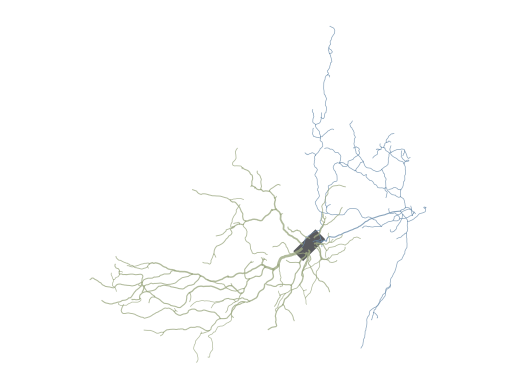

In [ ]:
golgi_morphology.vis2d(layout="projected", shape="line")

## Build the cell

The ``Cell`` object combines the reconstructed morphology with a control-volume discretization. The model helper paints passive properties across the whole morphology and adds different active conductances to soma, axon, and dendrite regions.


In [54]:
cell, regions, branch_groups = build_golgi_cell(golgi_morphology, cv_per_branch=1)

print(cell)
print("branch counts:", {name: len(indices) for name, indices in branch_groups.items()})
print("available regions:", [name for name, region in regions.items() if region is not None])


Cell(root='soma', n_branches=227, n_paint_rules=15, n_place_rules=0, initialized=False)
branch counts: {'soma': 1, 'axon': 75, 'dendrite': 151}
available regions: ['soma', 'axon', 'dendrite']


In [55]:
print("n_cv:", cell.n_cv)
print("first CVs:")
for cv in cell.cvs[:5]:
    print(
        f"  CV {cv.id}: branch_id={cv.branch_id}, "
        f"branch_type={cv.branch_type}, prox={cv.prox}, dist={cv.dist}"
    )


n_cv: 227
first CVs:
  CV 0: branch_id=0, branch_type=soma, prox=0.0, dist=1.0
  CV 1: branch_id=1, branch_type=axon, prox=0.0, dist=1.0
  CV 2: branch_id=2, branch_type=axon, prox=0.0, dist=1.0
  CV 3: branch_id=3, branch_type=axon, prox=0.0, dist=1.0
  CV 4: branch_id=4, branch_type=axon, prox=0.0, dist=1.0


## Simulation

A current clamp is placed near the soma root, and a voltage probe records the soma membrane potential. The simulation returns unit-aware traces, which we convert to milliseconds and millivolts before plotting.


In [56]:
cell.place(
    RootLocation(x=0.5),
    CurrentClamp(delay=5.0 * u.ms, durations=30.0 * u.ms, amplitudes=0.2 * u.nA),
)
cell.place(
    at("soma", 0.5),
    StateProbe(),
)


Cell(root='soma', n_branches=227, n_paint_rules=15, n_place_rules=2, initialized=False)

In [57]:
result = cell.run(dt=0.05 * u.ms, duration=50.0 * u.ms)

print("trace keys:", sorted(result.traces))
print("n timesteps:", int(result.time.shape[0]))
print("current time:", result.time[-1])


trace keys: ['soma(0.5)_v']
n timesteps: 1000
current time: 49.95 ms


In [58]:
times_ms = np.asarray(result.time.to_decimal(u.ms))
soma_v = np.asarray(result.traces["soma(0.5)_v"].to_decimal(u.mV))


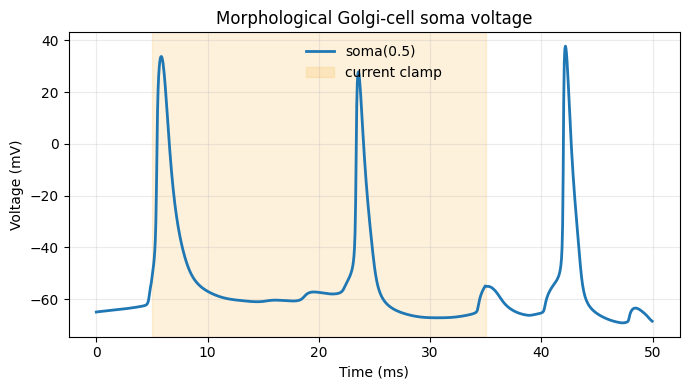

In [59]:
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times_ms, soma_v, color="#1f77b4", linewidth=2.0, label="soma(0.5)")
ax.axvspan(5.0, 35.0, color="#f8a413", alpha=0.15, label="current clamp")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title("Morphological Golgi-cell soma voltage")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
